In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [1]:
from VegasAfterglow import Fitter, ParamDef, Scale

In [3]:
help(ParamDef)

Help on class ParamDef in module VegasAfterglow.types:

class ParamDef(builtins.object)
 |  ParamDef(name: str, lower: float, upper: float, scale: VegasAfterglow.types.Scale = Scale.linear, initial: Optional[float] = None) -> None
 |  
 |  Single-parameter definition for MCMC.
 |  scale=LOG means we sample log10(x), then transform via 10**v.
 |  scale=FIXED means this param never appears in the sampler.
 |  
 |  Methods defined here:
 |  
 |  __eq__(self, other)
 |  
 |  __init__(self, name: str, lower: float, upper: float, scale: VegasAfterglow.types.Scale = Scale.linear, initial: Optional[float] = None) -> None
 |  
 |  __post_init__(self) -> None
 |      Catch obvious mistakes at construction time so the user sees the
 |      offending parameter immediately, not 30 seconds into the first MCMC
 |      step.
 |  
 |  __repr__(self)
 |  
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |  
 |  __dict__
 |      dictionary for

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from grb.io import read_data, filter_data
from grb.const import TRIGGER_TIME
from grb.analysis import Analyzer

from grb.functions import *
from grb.prior import *
from grb.extinction import host_galaxy_extinction, host_galaxy_extinction_curve

from grb.utils import unit_conversion
from grb.sed import *

## 7DT SED fit

In [3]:
df_sdt = read_data("sdt", correct_galactic_extinction=True, add_converted_flux=True)
x0 = pivot_finder(df_sdt["frequency_Hz"], df_sdt["flux_mJy_error"])
print(x0/1e14)

5.903434426266961


In [4]:
eta = host_galaxy_extinction_curve(df_sdt["frequency_Hz"])
combined_func = lambda x, *params: power_law(x, *params[:2], x0=x0) * host_galaxy_extinction(x, *params[2:], eta=eta)

param_bounds, prior = power_law_prior(data_type="sed")
param_bounds_ext, prior_ext = host_galaxy_extinction_prior()
param_bounds.update(param_bounds_ext)
prior.update(prior_ext)

alz_sed = Analyzer(df_sdt["frequency_Hz"], df_sdt["flux_mJy"], combined_func, data_type="sed", y_data_error=df_sdt["flux_mJy_error"], x_data_error=df_sdt["frequency_Hz_error"], param_bounds=param_bounds, prior=prior)
alz_sed.run(method="ultranest")

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-5e+01   [-52.1745..-52.1745]*| it/evals=4190/111606 eff=3.7644% N=300    0 0 0 0  
[ultranest] Likelihood function evaluations: 111717
[ultranest]   logZ = -61.52 +- 0.1384
[ultranest] Effective samples strategy satisfied (ESS = 1227.0, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.11 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.14, need <0.5)
[ultranest]   logZ error budget: single: 0.17 bs:0.14 tail:0.01 total:0.14 required:<0.50
[ultranest] done iterating.


<Axes: xlabel='Frequency', ylabel='Flux'>

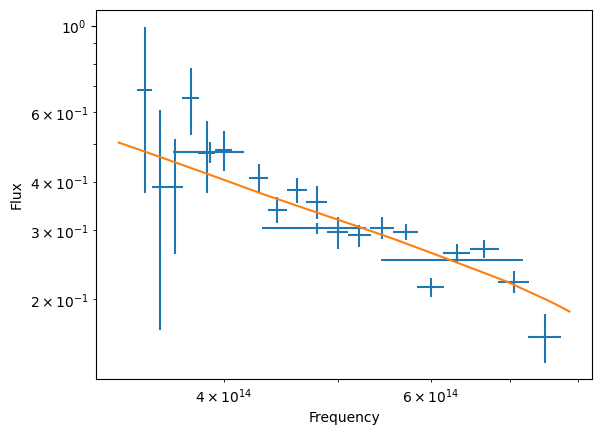

In [5]:
alz_sed.plot_data()
alz_sed.plot_model()

In [6]:
alz_sed.best_fit_params

[0.3313081761192561, 0.8962798386255719, 0.18079227291148947]

In [21]:
df_filtered

,time,time_high,time_low,flux,flux_high,flux_low
0,454.429,14.115,-15.973,1.076650e-10,2.352922e-11,-2.352922e-11
1,481.494,17.138,-12.949,1.051996e-10,2.378175e-11,-2.378175e-11
2,513.174,15.546,-14.542,1.149534e-10,2.523410e-11,-2.523410e-11
3,543.085,15.723,-14.365,1.156598e-10,2.602390e-11,-2.602390e-11
4,576.041,10.348,-17.233,1.410534e-10,2.961151e-11,-2.961151e-11
5,600.010,13.959,-13.621,1.251870e-10,2.739906e-11,-2.739906e-11
6,629.154,9.888,-15.185,1.339456e-10,2.949091e-11,-2.949091e-11
7,654.166,14.963,-15.124,1.068586e-10,2.411894e-11,-2.411894e-11
8,690.257,13.975,-21.127,1.018350e-10,2.177275e-11,-2.177275e-11
9,721.167,18.168,-16.935,9.894327e-11,2.178441e-11,-2.178441e-11


In [24]:
df_xrt = read_data("xrt")
df_filtered = filter_data(df_xrt, exclude_time_range = (3e3,  1e4))
y_err = np.array([max(np.abs(high), np.abs(low)) for high, low in zip(df_filtered["flux_high"], df_filtered["flux_low"])])
alz_xrt = Analyzer(df_filtered["time"]/3600, df_filtered["flux"], power_law, y_data_error=y_err)
alz_xrt.run(method="curve_fit")

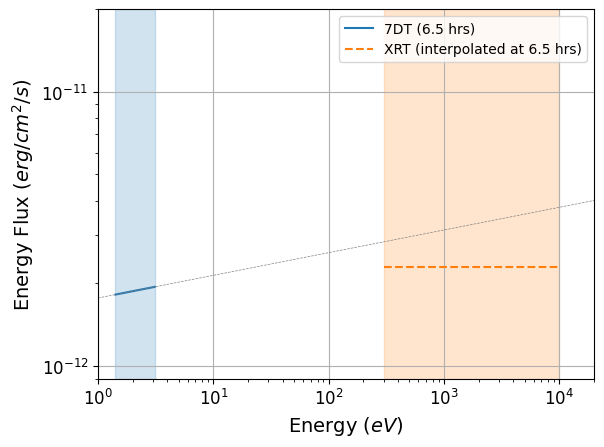

In [25]:
ax = plt.gca()

nu_grid = np.geomspace(min(alz_sed.x_data), max(alz_sed.x_data), 100)

power_law_sed = lambda x, *params: power_law(x, *params[:2], x0=x0)
dataset = alz_sed.get_posterior_predictive_curve(nu_grid, model=power_law_sed, param_indices=[0, 1])

plot_sed(nu_grid, power_law(nu_grid, *alz_sed.best_fit_params[:2], x0=x0), ax=ax, y_unit="sed", x_unit="eV", label="7DT (6.5 hrs)")
#plot_sed_from_samples(dataset, ax=ax, y_unit="sed", x_unit="eV")

extrapolate_range = np.geomspace(unit_conversion(1, "eV", "Hz"), unit_conversion(200, "keV", "Hz"), 100)
plot_sed(extrapolate_range, power_law(extrapolate_range, *alz_sed.best_fit_params[:2], x0=x0), ax=ax, y_unit="sed", x_unit="eV", color="gray", ls="--", lw=0.5)

ax.set_xlim(1, 20000)
ax.set_ylim(9e-13, 2e-11)

ax.axvspan(unit_conversion(min(alz_sed.x_data), "Hz", "eV"), unit_conversion(max(alz_sed.x_data), "Hz", "eV"), color="C0", alpha=0.2)
ax.axvspan(300, 10000, color="C1", alpha=0.2)

ax.plot([300, 10000], [alz_xrt.model(6.5), alz_xrt.model(6.5)], color="C1", ls="--", label="XRT (interpolated at 6.5 hrs)")
ax.legend()
ax.grid()

In [ ]:
from grb.utils import unit_conversion

In [ ]:
10**((np.log10(10000)+np.log10(300))/2)

In [ ]:
data = alz_sed.get_posterior_predictive_curve([unit_conversion(2000, "eV", "Hz")], model=power_law_sed, param_indices=[0, 1])

In [ ]:
data_erg = mJy_to_erg_cm2_s(data[0][1:], unit_conversion(2000, "eV", "Hz"))

In [ ]:
alz_xrt.plot_data(label="XRT")
ax = alz_xrt.plot_model(color="red", lw=0.5, alpha=0.5)
ax.errorbar(6.5, data_erg[1], yerr=[[data_erg[1]-data_erg[0]], [data_erg[2]-data_erg[1]]])
ax.axvline(6.5, color="C1", ls=":", label="XRT (predicted at 6.5 hrs)")


In [1]:
ls

data/  modeling/       __pycache__/      run.ipynb       template.py
grb/   modeling.ipynb  requirements.txt  spectrum.ipynb  update_time.py


In [2]:
ls /data/lyman/data1/7DT01/2026-05-02_gain2750/

7DT01_20260502_231433_T02386_m650_1x1_100.0s_0000.fits
7DT01_20260502_231433_T02386_m650_1x1_100.0s_0000.head
7DT01_20260502_231621_T02386_m650_1x1_100.0s_0001.fits
7DT01_20260502_231621_T02386_m650_1x1_100.0s_0001.head
7DT01_20260502_231809_T02386_m650_1x1_100.0s_0002.fits
7DT01_20260502_231809_T02386_m650_1x1_100.0s_0002.head
7DT01_20260502_232015_T02386_m769w_1x1_100.0s_0000.fits
7DT01_20260502_232015_T02386_m769w_1x1_100.0s_0000.head
7DT01_20260502_232203_T02386_m769w_1x1_100.0s_0001.fits
7DT01_20260502_232203_T02386_m769w_1x1_100.0s_0001.head
7DT01_20260502_232352_T02386_m769w_1x1_100.0s_0002.fits
7DT01_20260502_232352_T02386_m769w_1x1_100.0s_0002.head
7DT01_20260502_232610_T02385_m650_1x1_100.0s_0000.fits
7DT01_20260502_232610_T02385_m650_1x1_100.0s_0000.head
7DT01_20260502_232759_T02385_m650_1x1_100.0s_0001.fits
7DT01_20260502_232759_T02385_m650_1x1_100.0s_0001.head
7DT01_20260502_232947_T02385_m650_1x1_100.0s_0002.fits
7DT01_20260502_232947_T02385_m650_1x1_100.0s_0002.head
7DT0

In [3]:
ls *

modeling.ipynb    run.ipynb       template.py
requirements.txt  spectrum.ipynb  update_time.py

data:
circular.xlsx               i_data.csv     sdt.csv  xrt_fit.png  xrt_index.csv
host_galaxy_extinction.csv  raw_data.xlsx  xrt.csv  xrt.fnu.csv

grb:
analysis.py    fit.py        __init__.pyc   modeling.py   sed.py
const.py       functions.py  io.py          prior.py      utils.py
extinction.py  __init__.py   lightcurve.py  __pycache__/

modeling:
0108027v1.pdf            late_phase.py
early_phase_plotting.py  partial_data_plotting.py
early_phase.py           partial_data.py*
final_model_plotting.py  __pycache__/
final_model.py           spectral_index_interpolator.py
fit_results/             test/
late_phase_plotting.py   utils.py

__pycache__:
fit_xrt_i_ism_fs_rs.cpython-39.pyc


In [7]:
ls /data/lyman/data1/7DT01/2026-05-02_gain2750/*FLAT*.fits

/data/lyman/data1/7DT01/2026-05-02_gain2750/7DT01_20260503_104350_FLAT_g_1x1_10.4s_0000.fits
/data/lyman/data1/7DT01/2026-05-02_gain2750/7DT01_20260503_104408_FLAT_g_1x1_9.9s_0001.fits
/data/lyman/data1/7DT01/2026-05-02_gain2750/7DT01_20260503_104426_FLAT_g_1x1_9.3s_0002.fits
/data/lyman/data1/7DT01/2026-05-02_gain2750/7DT01_20260503_104443_FLAT_g_1x1_8.7s_0003.fits
/data/lyman/data1/7DT01/2026-05-02_gain2750/7DT01_20260503_104500_FLAT_g_1x1_8.2s_0004.fits
/data/lyman/data1/7DT01/2026-05-02_gain2750/7DT01_20260503_104517_FLAT_g_1x1_7.7s_0005.fits
/data/lyman/data1/7DT01/2026-05-02_gain2750/7DT01_20260503_104533_FLAT_g_1x1_7.2s_0006.fits
/data/lyman/data1/7DT01/2026-05-02_gain2750/7DT01_20260503_104548_FLAT_g_1x1_6.8s_0007.fits
/data/lyman/data1/7DT01/2026-05-02_gain2750/7DT01_20260503_104603_FLAT_g_1x1_6.4s_0008.fits
/data/lyman/data1/7DT01/2026-05-02_gain2750/7DT01_20260503_104627_FLAT_r_1x1_10.4s_0000.fits
/data/lyman/data1/7DT01/2026-05-02_gain2750/7DT01_20260503_104645_FLAT_r_1x1_9